In [44]:
import healpix as hp
import numpy as np
import xarray as xr
import intake
import numcodecs
import zarr

import easygems.healpix as egh
import easygems.remap as egr

import matplotlib.pyplot as plt

import dask.array as da

import glob
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts

In [45]:
plt.rcParams['figure.figsize'] = [12, 8]

In [46]:
current_location = "NCAR"
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]

In [52]:
hcat = intake.open_catalog("https://tcodata.mpimet.mpg.de/internal.yaml")
hera5=hcat["HERA5"](time='PT1H').to_dask().pipe(egh.attach_coords) 
hera5

<xarray.Dataset> Size: 48TB
Dimensions:    (time: 120504, cell: 196608, level: 29)
Coordinates:
    latitude   (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * level      (level) int64 232B 50 70 100 125 150 175 ... 900 925 950 975 1000
    longitude  (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * time       (time) datetime64[ns] 964kB 2010-01-01 ... 2023-09-30T23:00:00
    crs        int64 8B 0
  * cell       (cell) int64 2MB 0 1 2 3 4 ... 196603 196604 196605 196606 196607
    lat        (cell) float64 2MB 0.2984 0.5968 0.5968 ... -0.5968 -0.2984
    lon        (cell) float64 2MB 45.0 45.35 44.65 45.0 ... 315.4 314.6 315.0
Data variables: (12/72)
    100u       (time, cell) float32 95GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    100v       (time, cell) float32 95GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    10u        (time, cell) float32 95GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    10v        (time, cell) float32 95GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    2d         (time, cell) float32 95GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    2t         (time, cell) float32 95GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    ...         ...
    isor       (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
    lsm        (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
    sdfor      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
    sdor       (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
    slor       (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
    z_sfc      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
Attributes:
    acknowledgment:  Contains modified Copernicus Climate Change Service info...
    contact:         lukas.kluft@mpimet.mpg.de
    creator:         Lukas Kluft
    description:     Selected variables from ERA5, restructured and saved on ...
    institution:     Max Planck Institute for Meteorology
    source:          Post-processed dataset based on the ERA5 mirror located ...
    title:           HERA5 - HEALPixelation of ERA5

In [4]:
# Load dataset
filelist = ['scream_ne120','icon_d3hp003','casesm2_10km_nocumulus','nicam_gl11',
            'um_glm_n2560_RAL3p3']#,'um_glm_n1280_GAL9','um_glm_n1280_CoMA9_TBv1p2']
ds = {}
for fn in filelist:
    # get model name
    if 'um_glm' in fn:
        mn = fn.split('_')[0] + '_' + fn.split('_')[-1]
    else:
        mn = fn.split('_')[0]
        
    if 'scream' in fn:
        ds[mn] = cat[fn](zoom=4).to_dask().pipe(egh.attach_coords) 
    elif 'icon' in fn:
        ds[mn] = cat[fn](time_method='mean',time='P1D',zoom=4).to_dask().pipe(egh.attach_coords) 
    elif 'um_glm' in fn:
        ds[mn] = cat[fn](zoom=4,time='PT1H').to_dask().pipe(egh.attach_coords) 
    else:
        ds[mn] = cat[fn](zoom=4,time='PT3H').to_dask().pipe(egh.attach_coords) 



### Make a list of variables: reduce ds to this set, reduce time to monthly then save

In [5]:
varlist=['clt','rlut','rlutcs','rsut','rsutcs','rsdt','pr']
models=list(ds.keys())

In [6]:
#ds[models[3]][varlist]

In [ ]:
#del dsall,combined_ds

In [23]:
## Loop over model, make a monthly mean and try to merge along the model dimension into a single dataset...
# This is slow for online data....even at zoom 6.

dsall=[]

for m in models:
    print(m)
    ds_model=ds[m][varlist].groupby('time.month').mean('time')
    ds_model = ds_model.expand_dims(model=[m])
    dsall.append(ds_model)

combined_ds = xr.concat(dsall, dim='model',join='outer')

scream
icon
casesm2
nicam
um_RAL3p3


In [25]:
#combined_ds

### Read Back Processed Array

In [8]:
pth='/glade/derecho/scratch/andrew/hackathon/'
fn='combined_var6_z4.nc'

write = False

if write: 
    combined_ds.to_netcdf(pth+fn)
else:
    combined_ds=xr.open_dataset(pth+fn)
    varlist=list(combined_ds.data_vars)
    models=list(combined_ds.model)

In [23]:
# read back data here...(will need to read variables and models)

varlist

['clt', 'rlut', 'rlutcs', 'rsut', 'rsutcs', 'rsdt', 'pr']

### Load CERES data

In [38]:
ceres=cat['CERES_EBAF'](zoom=4).to_dask().pipe(egh.attach_coords) 

#monthly mean.

ceresmo=ceres.groupby('time.month').mean()

zmceres=ceresmo.groupby("lat").mean()

In [39]:
zmceres

<xarray.Dataset> Size: 34kB
Dimensions:                      (lat: 63, month: 12)
Coordinates:
    crs                          int64 8B 0
  * month                        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat                          (lat) float64 504B -87.08 -84.15 ... 87.08
Data variables:
    cldarea_total_daynight_mon   (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    cldpress_total_daynight_mon  (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    cldtau_total_day_mon         (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    cldtemp_total_daynight_mon   (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    solar_mon                    (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    toa_lw_all_mon               (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    toa_lw_clr_c_mon             (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    toa_net_all_mon              (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    toa_net_clr_c_mon            (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    toa_sw_all_mon               (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
    toa_sw_clr_c_mon             (lat, month) float32 3kB dask.array<chunksize=(63, 12), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF-TOA_L3B004.2.1
    comment:      Climatology from 07/2005 to 06/2015
    institution:  NASA/LaRC (Langley Research Center) Hampton, Va
    title:        CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Monthly...
    version:      Edition 4.2.1; Release Date November 25, 2024

### Zonal Mean

In [9]:
### Zonal Mean: Loop over variables (may be better to use UXarray...) and plot each model.
zm=combined_ds.groupby("lat").mean()

### Test: Plot one variable

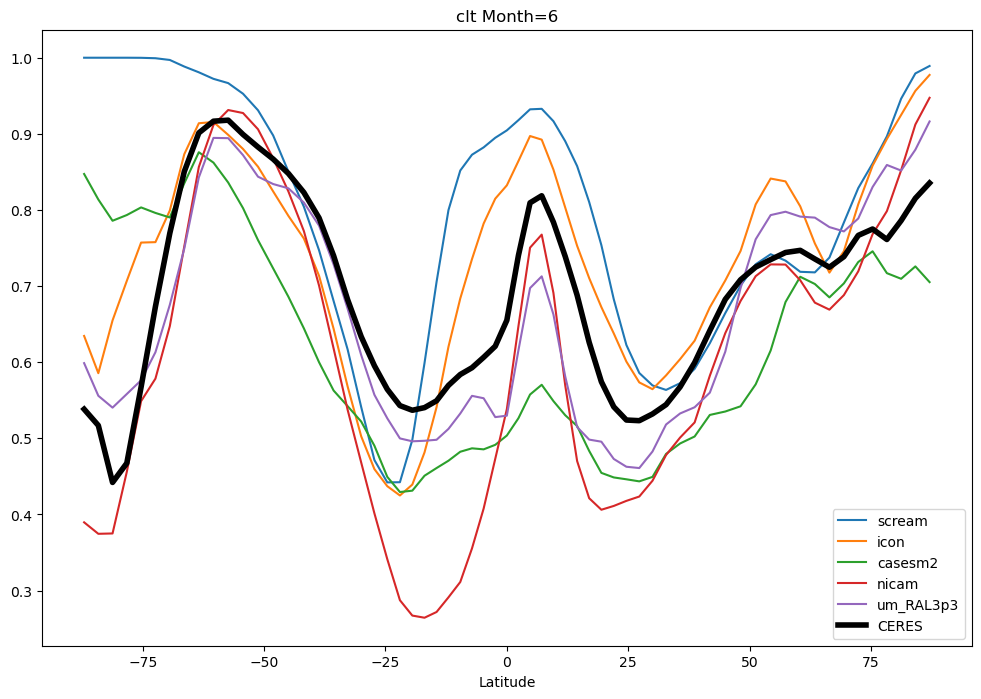

In [42]:
v=0
mo=6
for m in models:
    plt.plot(zm.lat,zm[varlist[v]].sel(model=m,month=mo),label=m)
plt.title(varlist[v]+" Month="+str(mo))

plt.plot(zmceres.lat,zmceres.cldarea_total_daynight_mon.sel(month=mo)/100.,label='CERES',linewidth=4,color='black')

plt.xlabel("Latitude")
plt.legend()

### Multi-Variable (multi-panel)

In [ ]:
# All variables (annual mean)
# Seasonal? DJF, JJA (or monthly by latitude bands)

### Original Zonal Mean Code: single variable

In [ ]:
### compute zonal mean: single variable
ds_clt_zonal = []
for mn in ds.keys():
    tmp = (ds[mn]['clt'].groupby("lat").mean()).compute().groupby('time.month').mean('time').mean('month')
    ds_clt_zonal.append(tmp.squeeze())
ds_clt_zonal = xr.concat(ds_clt_zonal,dim='model')
ds_clt_zonal['model'] = np.array([mn for mn in ds.keys()])

# plot zonal mean
fig=plt.figure(figsize=(12,4))
for mn in ds.keys():
    ds_clt_zonal.sel(model=mn).plot(label=mn.upper())
plt.legend()